In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
import random
import time
import numpy as np
import pandas as pd
from captum.attr import IntegratedGradients
import os
import random
import cv2
import matplotlib.pyplot as plt

/home/jrguezg/pytorch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class PilotNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 24, 5, stride=2),
            nn.ReLU(),
            nn.Conv2d(24, 36, 5, stride=2),
            nn.ReLU(),
            nn.Conv2d(36, 48, 5, stride=2),
            nn.ReLU(),
            nn.Conv2d(48, 64, 3),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 3, 66, 200)
            n_features = self.conv(dummy).view(1, -1).size(1)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_features, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
            nn.ReLU(),
            nn.Linear(10, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [8]:
model = PilotNet().to(device)
model.load_state_dict(torch.load("../carla_tests/weigths/30k_01_st_60_40.pth", map_location=device))
model.eval()

PilotNet(
  (conv): Sequential(
    (0): Conv2d(3, 24, kernel_size=(5, 5), stride=(2, 2))
    (1): ReLU()
    (2): Conv2d(24, 36, kernel_size=(5, 5), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(36, 48, kernel_size=(5, 5), stride=(2, 2))
    (5): ReLU()
    (6): Conv2d(48, 64, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (9): ReLU()
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=100, bias=True)
    (2): ReLU()
    (3): Linear(in_features=100, out_features=50, bias=True)
    (4): ReLU()
    (5): Linear(in_features=50, out_features=10, bias=True)
    (6): ReLU()
    (7): Linear(in_features=10, out_features=2, bias=True)
  )
)

In [5]:
preprocess = T.Compose([
    T.Resize((66, 200)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5])
])



In [9]:
df_path = "../common_utils/datasets/TOWN01_30K_ST"

images = [f for f in os.listdir(df_path) if f.endswith(".png")]

random_images = random.sample(images, 5)

imgs = []

for img in random_images:
    n_img = cv2.imread(os.path.join(df_path, img))
    n_img = cv2.cvtColor(n_img, cv2.COLOR_BGR2RGB)

    h, w  = n_img.shape[:2]

    cropped = n_img[int(h*0.35): ,:]

    imgs.append(cropped)


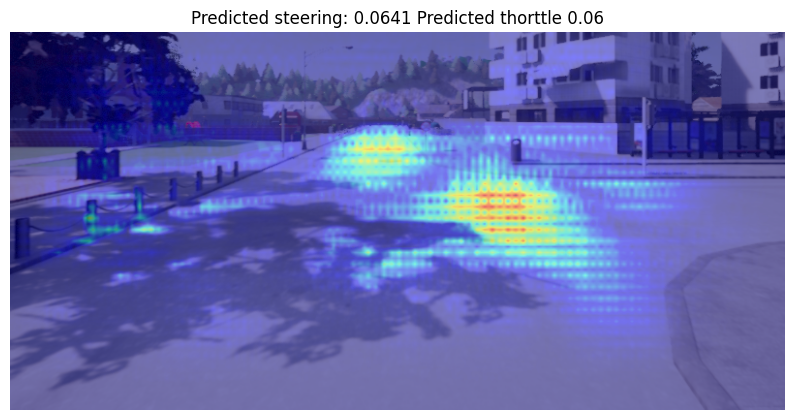

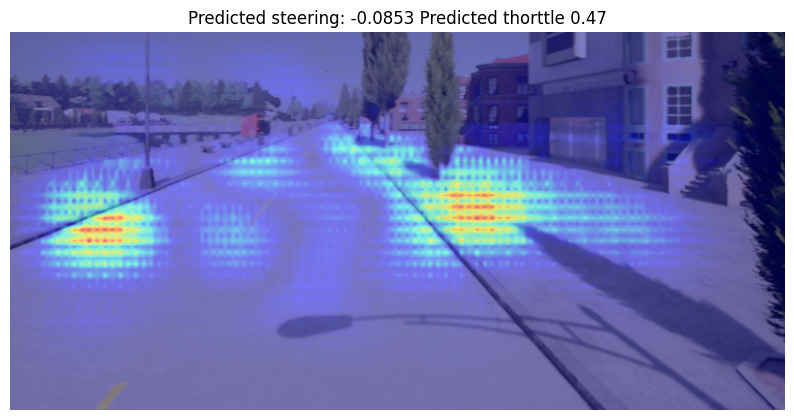

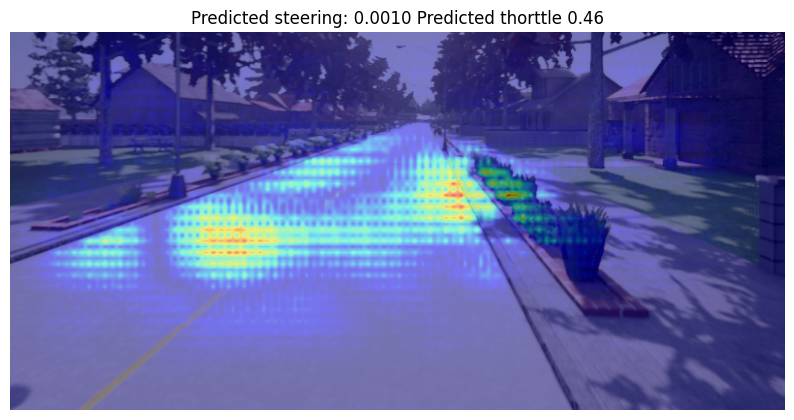

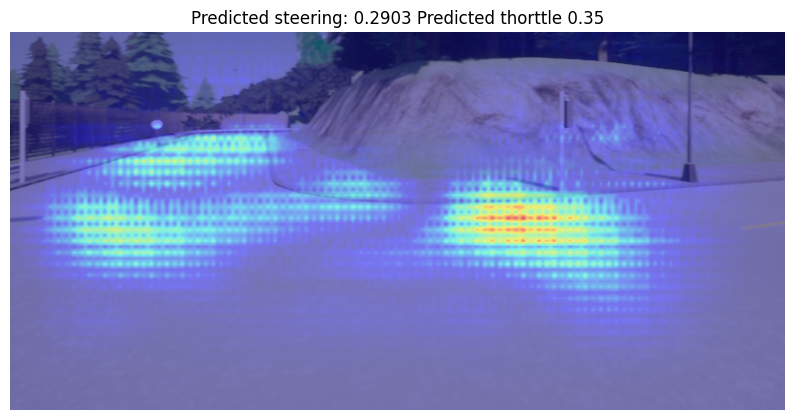

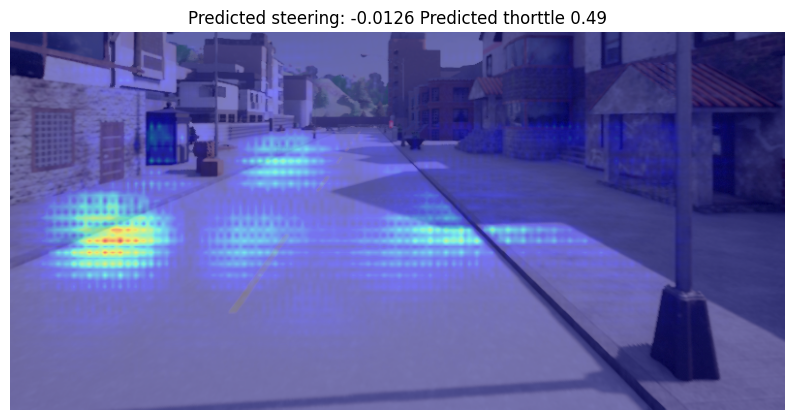

In [10]:
ig = IntegratedGradients(model)

for img_cropped in imgs:

    img_pil = Image.fromarray(img_cropped)
    input_tensor = preprocess(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor.to(device))
        pred_steer    = output[0, 0].item()
        pred_throttle = output[0, 1].item()

    attributions = ig.attribute(input_tensor, target=0)
    
    attr = attributions.squeeze().cpu().detach().numpy()
    attr = np.transpose(attr, (1, 2, 0))
    
    attr_combined = np.sum(np.abs(attr), axis=2)
    attr_combined = (attr_combined - attr_combined.min()) / (attr_combined.max() - attr_combined.min() + 1e-9)

    h_crop, w_crop = img_cropped.shape[:2]
    attr_resized = cv2.resize(attr_combined, (w_crop, h_crop))

    plt.figure(figsize=(10, 5))
    
    plt.imshow(img_cropped)
    plt.imshow(attr_resized, cmap='jet', alpha=0.5)
    
    plt.title(f"Predicted steering: {pred_steer:.4f} Predicted thorttle {pred_throttle:.2f}")
    plt.axis("off")
    plt.show()